In [1]:
import os
import mlflow
import mlflow.catboost
import catboost
import json

import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from optuna.integration import CatBoostPruningCallback
from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Настроиваем pandas
# Показывать все столбцы
pd.set_option("display.max_columns", None)
# Отображать полный текст в ячейках столбцов без усечения
pd.set_option("display.max_colwidth", None)

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
path = f"{PROJECT_ROOT}/mlruns"

# создаём mlruns и .trash, если нет
os.makedirs(os.path.join(path, ".trash"), exist_ok=True)

mlflow.set_tracking_uri(f"file://{path}")
mlflow.set_experiment("spaceship_titanic")

/opt/anaconda3/envs/spaceship_titanic_kaggle/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:///Users/admin/DataSince/Kaggle competitions/Spaceship '
 'Titanic/mlruns/689233284165520319'), creation_time=1767104868196, experiment_id='689233284165520319', last_update_time=1767104868196, lifecycle_stage='active', name='spaceship_titanic', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [4]:
df_train = pd.read_csv(('../data/processed/train_1'))
df_test = pd.read_csv('../data/processed/test_1')
df_train.shape, df_test.shape

((8693, 43), (4277, 42))

In [5]:
X = df_train.drop(["PassengerId", "Name", "Transported"], axis=1)
y = df_train.Transported
X.shape, y.shape

((8693, 40), (8693,))

In [6]:
X_test = df_test.drop(["PassengerId", "Name"], axis=1)
X_test.shape

(4277, 40)

In [7]:
cat_features = X.select_dtypes(include="object").columns.to_list()

X[cat_features] = X[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)

In [8]:
test_predict_list = []

train_features_list_1 = X.columns.to_list()
proba_oof = np.zeros(len(y))

params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'random_state': 42
}
n_splits = 5
auc_scores = []

# Создадим словарь для накопления важности признаков по каждому фолду
importances_dict = {col: [] for col in X.columns}

kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

with mlflow.start_run(run_name="catboost_cv5_baseline"):
    
    # логируем списки фич как артефакты (в json)
    mlflow.log_text(
        json.dumps(train_features_list_1, ensure_ascii=False, indent=2),
        artifact_file="train_features.json",
    )
    mlflow.log_text(
        json.dumps(list(cat_features), ensure_ascii=False, indent=2),
        artifact_file="cat_features.json",
    )

    # логируем гиперпараметры
    mlflow.log_params(params)
    mlflow.log_param("n_splits", n_splits) 

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(
            **params,
            cat_features=cat_features,
            verbose=False)
        model.fit(X_train, y_train)

        # Сохраним важности признаков в словаре
        importances = model.get_feature_importance()
        for col, imp in zip(X.columns, importances, strict=True):
            importances_dict[col].append(imp)

        val_pred = model.predict_proba(X_val)[:, 1]
        proba_oof[val_idx] = val_pred 
        
        auc = roc_auc_score(y_val, val_pred)
        auc_scores.append(auc)
        mlflow.log_metric(f"fold{fold}_auc", float(auc))
        print(f"fold{fold}_auc", float(auc))

        test_pred = model.predict_proba(X_test)[:, 1]
        test_predict_list.append(test_pred)

        
    cv_mean = float(np.mean(auc_scores))
    cv_std = float(np.std(auc_scores))

    mlflow.log_metric("cv_auc_mean", cv_mean)
    mlflow.log_metric("cv_auc_std", cv_std)

    features = importances_dict.keys()
    values = sorted(list([np.mean(v) for v in importances_dict.values()]))
    aggregated_importances = dict(zip(features, values))

    mlflow.log_text(
        json.dumps(aggregated_importances, ensure_ascii=False, indent=2),
        artifact_file="feature_importances_mean.json",
    )

    print("cv_mean, cv_std:", cv_mean, cv_std)

    thresholds = np.linspace(0, 1, 1001)
    accs = []
    
    for thr in thresholds:
        y_pred = (proba_oof >= thr).astype(int)
        accs.append(accuracy_score(y, y_pred))
    
    best_thr = thresholds[np.argmax(accs)]
    best_acc = max(accs)
    print("Best thr, best acc:", best_thr, best_acc)
    
    mlflow.log_param("best_thr", best_thr)
    mlflow.log_metric("best_acc", best_acc)

fold1_auc 0.9076943020259581
fold2_auc 0.9066717990232649
fold3_auc 0.910882183315079
fold4_auc 0.9021354080450256
fold5_auc 0.9034888263532528
cv_mean, cv_std: 0.906174503752516 0.0031063320321311726
Best thr, best acc: 0.523 0.8154837225353733


In [9]:
print("Acc at 0.5:", accuracy_score(y, proba_oof >= 0.5))
print(f"Acc at {best_thr}:", accuracy_score(y, proba_oof >= best_thr))

Acc at 0.5: 0.813643161164155
Acc at 0.523: 0.8154837225353733


In [10]:
test_predict_list

[array([0.53963237, 0.02607187, 0.99308903, ..., 0.97788978, 0.84170486,
        0.60519115]),
 array([0.4958737 , 0.02494479, 0.98741174, ..., 0.97382831, 0.70878713,
        0.61325813]),
 array([0.4858128 , 0.03401678, 0.98351376, ..., 0.96615743, 0.81562842,
        0.68210325]),
 array([0.57926201, 0.02985665, 0.98379595, ..., 0.97165571, 0.59621037,
        0.73756163]),
 array([0.53056744, 0.02973422, 0.99009451, ..., 0.97073127, 0.67166477,
        0.66451582])]

In [11]:
# test_predict_list: список из n_folds массивов длины n_test
# auc_scores: список AUC по фолдам, длина n_folds
# best_thr: найденный порог по proba_oof

test_predict_list = [np.array(p) for p in test_predict_list]
auc_scores = np.array(auc_scores, dtype=float)

# нормируем веса
weights = auc_scores / auc_scores.sum()
print(weights)

# (n_folds, n_test)
test_preds_stack = np.vstack(test_predict_list)

# взвешенный ансамбль по тесту
test_pred_weighted = np.average(test_preds_stack, axis=0, weights=weights) 

# бинарные предикты по найденному порогу
test_pred_bool = (test_pred_weighted >= best_thr).astype(bool)
test_pred_bool

[0.20033543 0.20010976 0.20103902 0.19910854 0.19940725]


array([ True, False,  True, ...,  True,  True,  True])

In [12]:
len(test_pred_bool)

4277

In [13]:
submision = df_test[["PassengerId"]].copy() 
submision["Transported"] = test_pred_bool
submision.to_csv("../predictions/submission_0.csv", index=False)
submision.shape

(4277, 2)

In [14]:
submision.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [15]:
importances_dict

{'HomePlanet': [np.float64(7.271775389205454),
  np.float64(6.10297112279212),
  np.float64(5.872735071663417),
  np.float64(5.647029410705597),
  np.float64(6.950279745226701)],
 'CryoSleep': [np.float64(1.7532726506310319),
  np.float64(1.873523362903628),
  np.float64(2.0996154805704874),
  np.float64(1.466026829035391),
  np.float64(2.6399000827378503)],
 'Cabin': [np.float64(0.07545529253785717),
  np.float64(0.6012473134823747),
  np.float64(0.3163561767409172),
  np.float64(0.6240157701870894),
  np.float64(0.06304852670980136)],
 'Destination': [np.float64(2.743791958447035),
  np.float64(3.218999328017694),
  np.float64(2.536461048340783),
  np.float64(2.79520513970522),
  np.float64(2.978762123817261)],
 'Age': [np.float64(2.0806187619548204),
  np.float64(2.162067190092559),
  np.float64(1.9770971448159453),
  np.float64(1.6494259599357062),
  np.float64(2.183490809152298)],
 'VIP': [np.float64(0.0781752781849133),
  np.float64(0.030443430832017507),
  np.float64(0.051671080

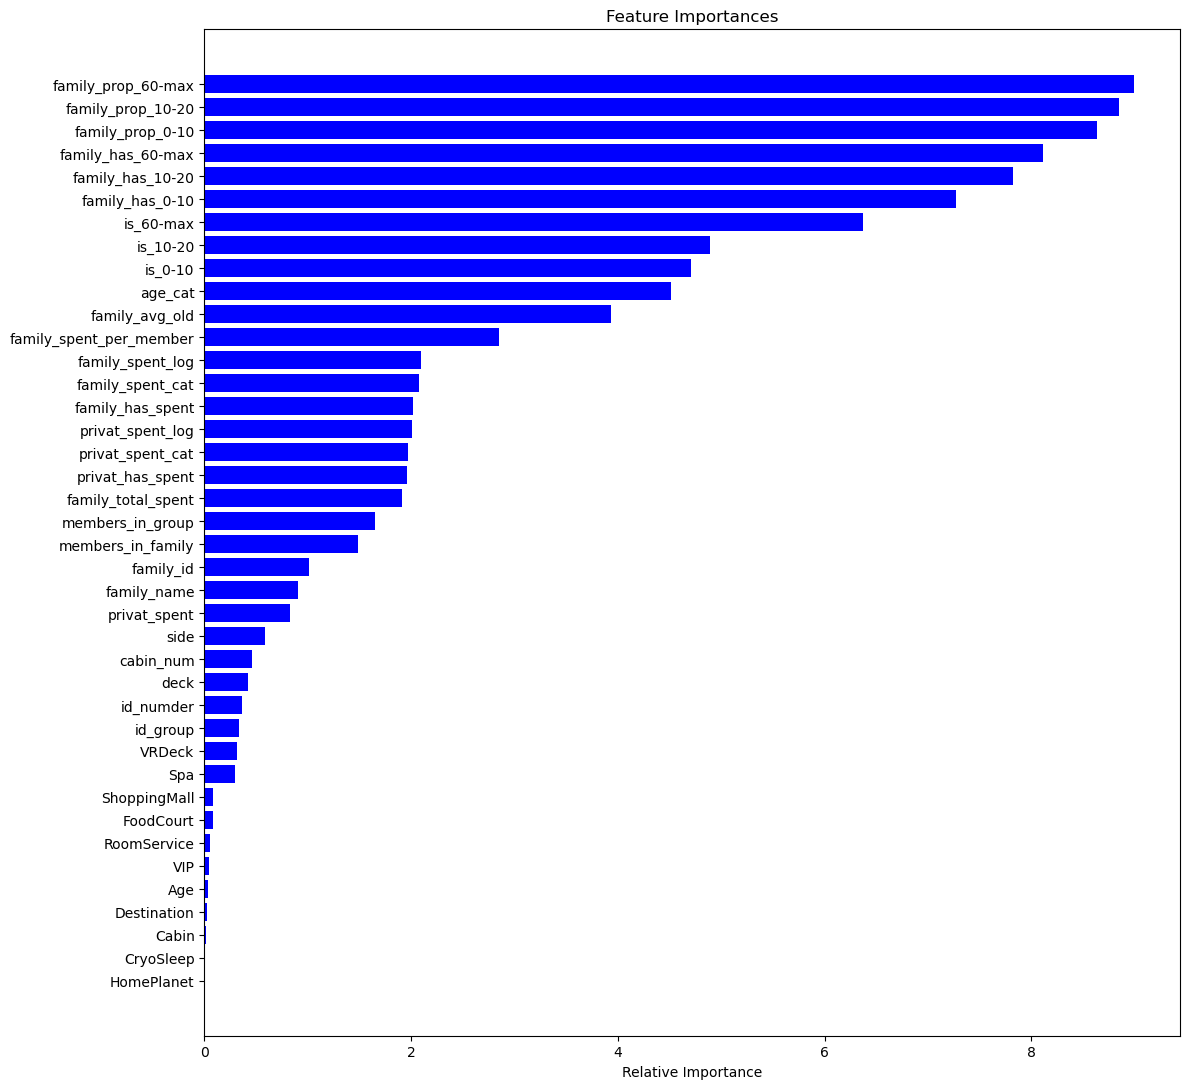

In [16]:
# Визуализируем важности признаков
features = importances_dict.keys()
values = sorted(list([np.mean(v) for v in importances_dict.values()]))

plt.figure(figsize=(12, 11))
plt.barh(features, values, color="blue")
plt.xlabel("Relative Importance")
plt.title("Feature Importances")
# plt.gca().invert_yaxis()  # Самый важный сверху
plt.tight_layout()
plt.show()